# Employee Attrition Analysis

## Business Understanding

---

## Background

The company has been experiencing a notable rate of employee resignations over recent years. While some turnover is normal and even healthy for any organization, the current pattern suggests something more concerning — valuable employees are choosing to leave, and the company is struggling to retain its talent.

This analysis was initiated to understand why employees are leaving, identify the factors that contribute most to their decisions, and provide practical recommendations that HR and management can act on.

---

## What Is Employee Attrition?

Employee attrition refers to the gradual reduction in the workforce as employees leave — whether through resignation, retirement, or termination — without being immediately replaced.

In this project, the focus is specifically on **voluntary attrition**: employees who made the personal decision to leave the company on their own.

It's worth distinguishing attrition from turnover:

- **Attrition** — the position may not be ref

---



# Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
df=pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [4]:
df.shape

(1470, 35)

In [5]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [6]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [8]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [9]:
df.sample(3)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
635,35,No,Travel_Rarely,607,Research & Development,9,3,Life Sciences,1,880,...,2,80,1,17,2,3,17,14,5,15
963,38,No,Travel_Rarely,1009,Sales,2,2,Life Sciences,1,1355,...,4,80,1,11,3,3,7,7,1,7
1301,58,No,Non-Travel,350,Sales,2,3,Medical,1,1824,...,4,80,1,37,0,2,16,9,14,14


In [10]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [11]:
df.nunique()

,0
Age,43
Attrition,2
BusinessTravel,3
DailyRate,886
Department,3
DistanceFromHome,29
Education,5
EducationField,6
EmployeeCount,1
EmployeeNumber,1470


In [12]:
#Missing Value
mising=df.isnull().sum()
print(mising[mising>0])
print(df.isnull().sum())

Series([], dtype: int64)
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentR

In [13]:
#duplicate
dulicates=df.duplicated().sum()
print(dulicates)

0


In [14]:
#outlier
all_num_cols = [
        'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
    'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears',
    'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsSinceLastPromotion', 'YearsWithCurrManager']

for col in all_num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1


    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]

    if outliers_count > 0:
        print(f"{col}: {outliers_count} Outliers")


MonthlyIncome: 114 Outliers
NumCompaniesWorked: 52 Outliers
TotalWorkingYears: 63 Outliers
TrainingTimesLastYear: 238 Outliers
YearsAtCompany: 104 Outliers
YearsInCurrentRole: 21 Outliers
YearsSinceLastPromotion: 107 Outliers
YearsWithCurrManager: 14 Outliers


# Dataset Overview
After a thorough examination of the dataset, here are the key observations:

# Data Size:
The dataset contains 1,470 rows and 35 columns. Each row represents one employee, and each column represents a characteristic or attribute of that employee. In other words, we have complete information about 1,470 employees.

# Data Types
We have two types of data:

First: Numerical Data (26 columns)
Such as Age, MonthlyIncome, TotalWorkingYears, and DistanceFromHome. These columns are ready for statistical analysis directly.

Second: Categorical or Text Data (9 columns)
Such as Gender, Department, JobRole, and MaritalStatus. These columns need to be encoded into numbers before analysis.

# Data Quality
Fortunately, the data is very clean, which is excellent:

No missing values, every cell has data.
No duplicate rows, each employee is represented only once.
No obvious errors in recording.

This means we don't need to spend much time cleaning the data and can focus on the analysis itself.

Columns with No Analytical Value
I found 3 columns with constant values that won't add anything to the analysis:

EmployeeCount, value is 1 for all rows.
Over18, value is Y for all rows since all employees are obviously over 18.
StandardHours, value is 80 for all rows.

These columns will be removed because they don't differentiate between employees.

# Target Variable
The variable we want to understand is Attrition, whether the employee left the company or is still there.

The result:
1,233 employees are still with the company, representing 83.9%.
237 employees left the company, representing 16.1%.

This means the attrition rate is approximately 16%.

# Important Notes
First: The data is imbalanced
The number of employees who left, 237, is much smaller than those who stayed, 1,233. This is normal in HR projects, but we need to be careful not to over-interpret the percentages.

Second: The 16% attrition rate deserves attention
This rate is higher than the global average, which ranges between 10 and 12 percent. This means the company genuinely needs to intervene.

Third: There is significant diversity in the data
We have employees of different ages, ranging from 18 to 60 years, from different departments, and with varying salaries. This will help us find real patterns.


# Quick Reference
Aspect	Finding
Rows	1,470 employees
Columns	35 attributes
Numerical Columns	26
Categorical Columns	9
Missing Values	None
Duplicates	None
Constant Columns	EmployeeCount, Over18, StandardHours
Target Variable	Attrition, Yes or No
Attrition Rate	16.1%





################################################################################################################################################################################################################################################


# Data Preparation
Preparing the Data for Analysis
Before We Start
In this step, we will make changes to the data, but not just any changes. Every modification must have a clear reason. Our rule is: we don't change something just because it's common in other projects. We change it only when it makes sense for our specific data.

Here's what we'll do in this step:

Remove columns that don't add value

Add a numeric column for Attrition so we can calculate

Save a clean copy of the data

# Modification 1: Remove Unnecessary Columns
Why We're Doing This
During the data understanding phase, we found 3 columns where every value is the same across all rows:

EmployeeCount, value is 1 for all employees

Over18, value is Y for all employees

StandardHours, value is 80 for all employees

These columns don't differentiate between employees, so they won't help in any analysis.

There's also a fourth column called EmployeeNumber, which is just an identification number for each employee, not an attribute of the employee, so we won't need it in the analysis

In [15]:
# Create a copy of the original data
df_clean = df.copy()

# Remove unnecessary columns
df_clean = df_clean.drop(columns=['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'])

In [16]:
df_clean.shape

(1470, 31)

In [17]:
df_clean.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [18]:
# Add a numeric column for Attrition
df_clean['Attrition_Numeric'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})

In [19]:
df_clean['Attrition_Numeric'].value_counts()

,count
Attrition_Numeric,
0,1233
1,237


In [20]:
df_clean['Attrition_Numeric'].mean() * 100

np.float64(16.122448979591837)

In [21]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         


# Summary Step Data Preparation
Remove 4 columns	No analytical value	From 35 columns to 31
Add Attrition_Numeric	Easier calculations	New numeric column


########################################
# Exploratory Data Analysis (EDA)


#  Attrition Visualization

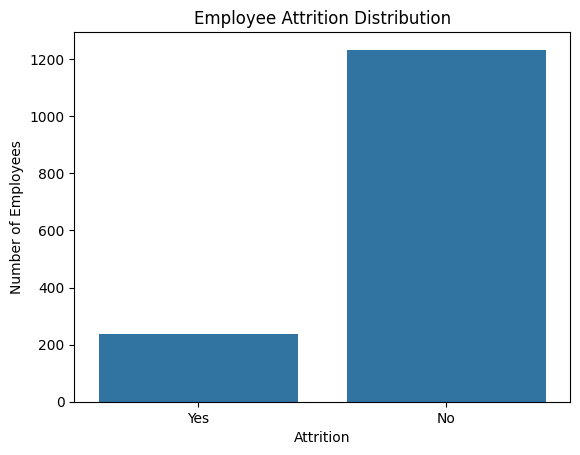

In [22]:
sns.countplot(data=df, x='Attrition')
plt.title('Employee Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.show()

# Interpretation:

The chart shows that the number of employees who stayed is much higher
than the number of employees who left the company.

#  Gender Distribution





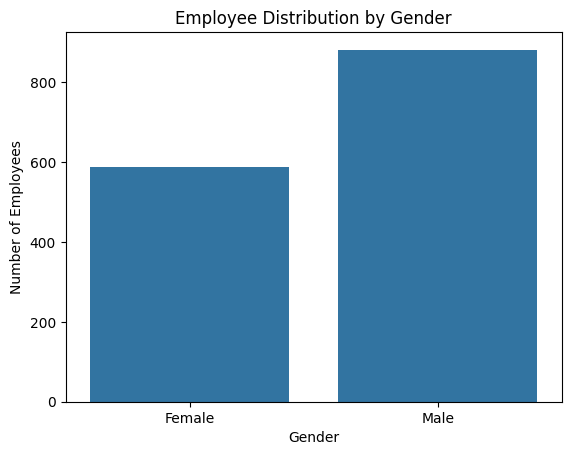

In [23]:

sns.countplot(data=df, x='Gender')
plt.title('Employee Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Employees')
plt.show()

Interpretation:

The dataset contains employees from both male and female groups. The chart shows the distribution of employees across the two gender categories.

# Age Distribution



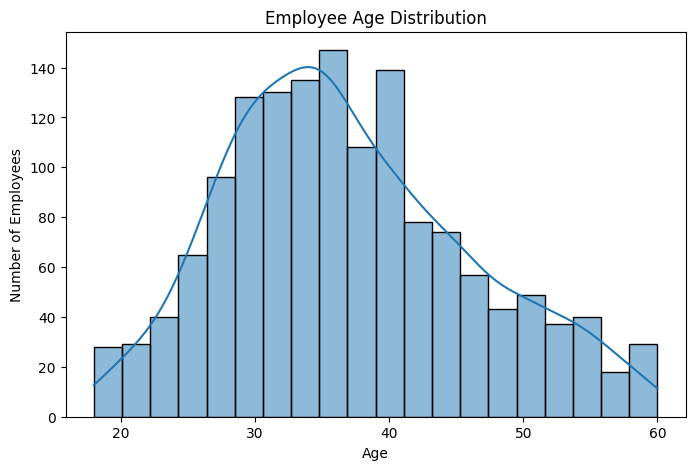

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x='Age', bins=20, kde=True)

plt.title('Employee Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Employees')
plt.show()

Interpretation:

The age distribution shows that employees are spread across different age groups. Most employees are concentrated within the working-age range represented in the dataset.

# Job Role Distribution



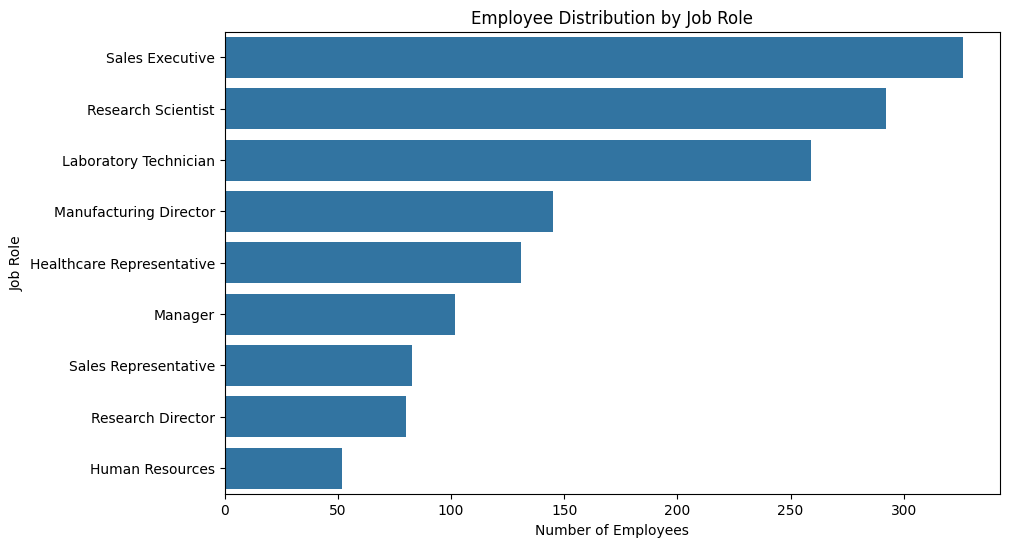

In [25]:
plt.figure(figsize=(10,6))

sns.countplot(data=df, y='JobRole')

plt.title('Employee Distribution by Job Role')
plt.xlabel('Number of Employees')
plt.ylabel('Job Role')
plt.show()


Interpretation:

The employees are distributed across several job roles. Some roles have considerably more employees than others, indicating differences in workforce size across positions.

# Monthly Income Distribution



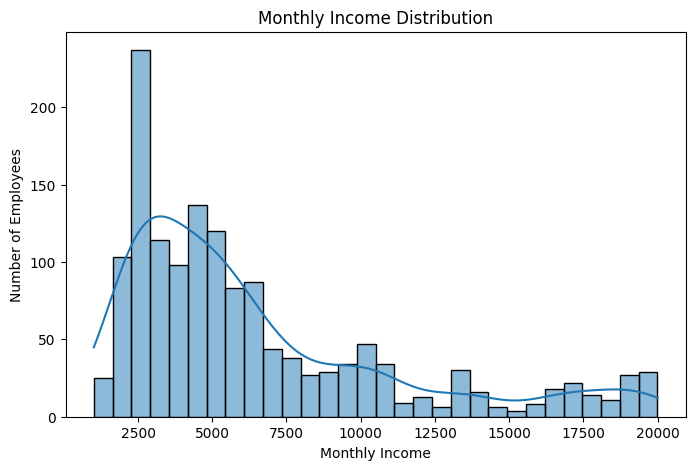

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x='MonthlyIncome', bins=30, kde=True)

plt.title('Monthly Income Distribution')
plt.xlabel('Monthly Income')
plt.ylabel('Number of Employees')
plt.show()

Interpretation:

Monthly income varies considerably among employees.
The distribution shows differences in income levels across the workforce.

# Overtime Distribution



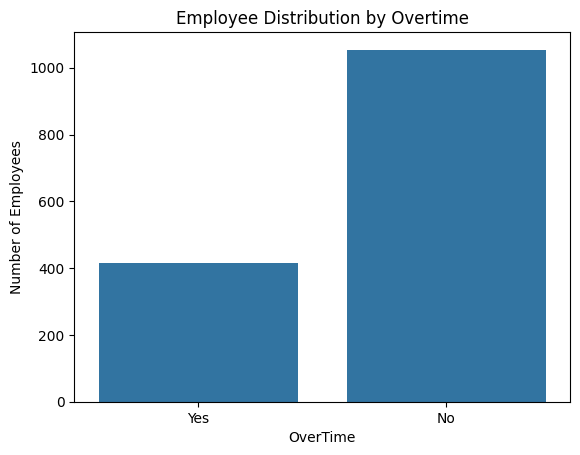

In [27]:
sns.countplot(data=df, x='OverTime')

plt.title('Employee Distribution by Overtime')
plt.xlabel('OverTime')
plt.ylabel('Number of Employees')
plt.show()

Interpretation:

The chart shows the number of employees who work overtime compared with
employees who do not work overtime.
This variable will be important when comparing overtime with employee attrition

# Q1 — How is employee attrition affected by gender?



In [28]:
gender_attrition = df.groupby('Gender')['Attrition'].value_counts().reset_index(name='Count')

In [29]:
fig = px.bar(
    gender_attrition,
    x='Gender',
    y='Count',
    color='Attrition',
    barmode='group',
    title='Employee Attrition by Gender'
)

fig.show()

 Interpretation

Attrition exists in both male and female employees.
The chart allows us to compare employees who stayed with those who left
within each gender group.

# Q2 — How is employee attrition affected by business travel?





In [30]:
travel_attrition = df.groupby('BusinessTravel')['Attrition'].value_counts().reset_index(name='Count')

In [31]:
fig = px.bar(
    travel_attrition,
    x='BusinessTravel',
    y='Count',
    color='Attrition',
    barmode='group',
    title='Employee Attrition by Business Travel'
)

fig.show()

Interpretation

Employees who travel frequently have a higher attrition rate than employees
who travel rarely or do not travel.

# Q3 — What is the effect of distance from home on employee attrition?




In [32]:
df['DistanceGroup'] = pd.cut(
    df['DistanceFromHome'],
    bins=[0, 5, 10, 20, 100],
    labels=['0-5', '6-10', '11-20', '20+']
)

In [34]:
distance_attrition = df.groupby('DistanceGroup', observed=True)['Attrition'].value_counts().reset_index(name='Count')

In [35]:
fig = px.bar(
    distance_attrition,
    x='DistanceGroup',
    y='Count',
    color='Attrition',
    barmode='group',
    title='Employee Attrition by Distance From Home'
)

fig.show()

Interpretation

Attrition tends to increase as the distance from home becomes larger.
Employees living more than 20 km from work show a higher attrition rate
than employees living closer to work.

# Q4 — Which department has the highest employee attrition?

In [36]:
department_attrition = df.groupby('Department')['Attrition'].value_counts().reset_index(name='Count')

fig = px.bar(
    department_attrition,
    x='Department',
    y='Count',
    color='Attrition',
    barmode='group',
    title='Employee Attrition by Department'
)

fig.show()

**Interpretation**

Sales has the highest attrition rate among the three departments.

# Q5 — What is the effect of years with the current manager on attrition?

In [37]:
manager_attrition = df.groupby('YearsWithCurrManager')['Attrition'].value_counts().reset_index(name='Count')

fig = px.bar(
    manager_attrition,
    x='YearsWithCurrManager',
    y='Count',
    color='Attrition',
    barmode='group',
    title='Attrition by Years With Current Manager'
)

fig.show()

**Interpretation**

Employees with fewer years with their current manager generally show higher attrition.
The value of 0 years has a noticeably higher attrition level than many longer-tenure groups.

# Q6 — Which job role has the highest employee attrition?

In [38]:
role_attrition = df.groupby('JobRole')['Attrition'].value_counts().reset_index(name='Count')

fig = px.bar(
    role_attrition,
    x='JobRole',
    y='Count',
    color='Attrition',
    barmode='group',
    title='Employee Attrition by Job Role'
)

fig.show()

**Interpretation**

Sales Representatives have the highest attrition rate among the job roles.

# Q7 — Is salary one of the main reasons behind employee attrition?

In [39]:
fig = px.box(
    df,
    x='Attrition',
    y='MonthlyIncome',
    color='Attrition',
    title='Monthly Income by Attrition'
)

fig.show()

**Interpretation**

Employees who left generally have lower monthly income than employees who stayed.
This suggests that salary may be associated with attrition, but this dataset alone cannot prove that salary is the direct reason employees leave.

# Q8 — Does the employee's education field play a role in attrition?

In [40]:
education_attrition = df.groupby('EducationField')['Attrition'].value_counts().reset_index(name='Count')

fig = px.bar(
    education_attrition,
    x='EducationField',
    y='Count',
    color='Attrition',
    barmode='group',
    title='Attrition by Education Field'
)

fig.show()

**Interpretation**

Attrition differs across education fields.
Human Resources and Technical Degree show relatively higher attrition rates than several other fields.

# Q9 — Does working overtime increase the likelihood of employee attrition?

In [41]:
overtime_attrition = df.groupby('OverTime')['Attrition'].value_counts().reset_index(name='Count')

fig = px.bar(
    overtime_attrition,
    x='OverTime',
    y='Count',
    color='Attrition',
    barmode='group',
    title='Employee Attrition by Overtime'
)

fig.show()

**Interpretation**

Employees who work overtime have a higher attrition rate than employees who do not.
This makes overtime an important factor to investigate in employee retention.

# Q10 — Is the work environment one of the reasons employees leave the company?

In [42]:
environment_attrition = df.groupby('EnvironmentSatisfaction')['Attrition'].value_counts().reset_index(name='Count')

fig = px.bar(
    environment_attrition,
    x='EnvironmentSatisfaction',
    y='Count',
    color='Attrition',
    barmode='group',
    title='Attrition by Environment Satisfaction'
)

fig.show()

**Interpretation**

Employees with lower environment satisfaction show higher attrition.
This suggests that the work environment may be associated with employees' decisions to leave.

# Q11 — What factors contribute the most to employee attrition?

**Interpretation**

Based on the previous analysis, some of the clearest patterns are related to overtime, monthly income, age, business travel, job role, job satisfaction, work-life balance, and years of experience.

These are associations in the dataset, not proof that one factor directly causes attrition.

# Q12 — What actions can the company take to improve employee retention?

**Theoretical / Business Answer**

The company can focus on the factors that showed higher attrition in the analysis, such as overtime, low satisfaction, lower income, frequent business travel, and early career stages.

Possible actions include reviewing workload, improving employee support, checking compensation levels, and paying closer attention to employees who show several risk factors together.

# Q13 — What is the relationship between employee age and attrition?

In [43]:
fig = px.box(
    df,
    x='Attrition',
    y='Age',
    color='Attrition',
    title='Age by Attrition'
)

fig.show()

**Interpretation**

Younger employees show higher attrition than older employees in this dataset.
The youngest age group has a noticeably higher attrition rate.

# Q14 — Is income a major factor affecting employee attrition?

In [44]:
fig = px.box(
    df,
    x='Attrition',
    y='MonthlyIncome',
    color='Attrition',
    title='Monthly Income and Attrition'
)

fig.show()

**Interpretation**

Employees who left have a lower typical monthly income than employees who stayed.
Income therefore appears to be an important factor associated with attrition.

# Q15 — Does the department in which an employee works affect attrition?

**Interpretation**

Yes, attrition rates differ between departments.
The department comparison in Q4 shows that Sales has the highest attrition rate among the three departments.

# Q16 — How does environment satisfaction affect employee attrition?

In [45]:
environment_attrition = df.groupby('EnvironmentSatisfaction')['Attrition'].value_counts().reset_index(name='Count')

fig = px.bar(
    environment_attrition,
    x='EnvironmentSatisfaction',
    y='Count',
    color='Attrition',
    barmode='group',
    title='Environment Satisfaction vs Attrition'
)

fig.show()

**Interpretation**

Lower environment satisfaction is associated with higher attrition.
Employees with the lowest satisfaction level have the highest attrition rate.

# Q17 — How does job satisfaction affect employee attrition?

In [46]:
job_satisfaction_attrition = df.groupby('JobSatisfaction')['Attrition'].value_counts().reset_index(name='Count')

fig = px.bar(
    job_satisfaction_attrition,
    x='JobSatisfaction',
    y='Count',
    color='Attrition',
    barmode='group',
    title='Job Satisfaction vs Attrition'
)

fig.show()

**Interpretation**

Attrition is higher among employees with lower job satisfaction.
The lowest satisfaction level has the highest attrition rate.

# Q18 — Do employee stock options have an impact on attrition?

In [47]:
stock_attrition = df.groupby('StockOptionLevel')['Attrition'].value_counts().reset_index(name='Count')

fig = px.bar(
    stock_attrition,
    x='StockOptionLevel',
    y='Count',
    color='Attrition',
    barmode='group',
    title='Stock Option Level vs Attrition'
)

fig.show()

**Interpretation**

Attrition is highest among employees with no stock options.
Employees with higher stock option levels generally show lower attrition in this dataset.

# Q19 — How does work-life balance affect overall attrition?

In [48]:
balance_attrition = df.groupby('WorkLifeBalance')['Attrition'].value_counts().reset_index(name='Count')

fig = px.bar(
    balance_attrition,
    x='WorkLifeBalance',
    y='Count',
    color='Attrition',
    barmode='group',
    title='Work-Life Balance vs Attrition'
)

fig.show()

**Interpretation**

Employees with lower work-life balance tend to have higher attrition.
The lowest work-life balance level has the highest attrition rate.

# Q20 — How does total work experience affect employee attrition?

In [49]:
fig = px.box(
    df,
    x='Attrition',
    y='TotalWorkingYears',
    color='Attrition',
    title='Total Working Years vs Attrition'
)

fig.show()

**Interpretation**

Employees with less total work experience show higher attrition.
This suggests that early-career employees may require more attention for retention.

# Q21 — How does the number of years in the current role affect attrition?

In [50]:
role_years_attrition = df.groupby('YearsInCurrentRole')['Attrition'].value_counts().reset_index(name='Count')

fig = px.bar(
    role_years_attrition,
    x='YearsInCurrentRole',
    y='Count',
    color='Attrition',
    barmode='group',
    title='Years in Current Role vs Attrition'
)

fig.show()

**Interpretation**

Employees with fewer years in their current role generally show higher attrition.
Employees with 0 years in the current role have a noticeably high attrition rate.

# Q22 — Does salary increase percentage have an impact on employee attrition?

In [51]:
hike_attrition = df.groupby('PercentSalaryHike')['Attrition'].value_counts().reset_index(name='Count')

fig = px.bar(
    hike_attrition,
    x='PercentSalaryHike',
    y='Count',
    color='Attrition',
    barmode='group',
    title='Salary Increase Percentage vs Attrition'
)

fig.show()

**Interpretation**

Attrition varies across salary increase percentages, but the pattern is not consistently increasing or decreasing.
Therefore, salary increase percentage alone does not give a clear explanation for attrition.

# Q23 — Could managers be one of the reasons employees resign?

In [52]:
manager_attrition = df.groupby('YearsWithCurrManager')['Attrition'].value_counts().reset_index(name='Count')

fig = px.bar(
    manager_attrition,
    x='YearsWithCurrManager',
    y='Count',
    color='Attrition',
    barmode='group',
    title='Years With Current Manager vs Attrition'
)

fig.show()

**Interpretation**

Employees with fewer years with their current manager generally have higher attrition.
This may indicate that the manager relationship is worth investigating, but the dataset does not prove that managers directly cause resignations.

# Q24 — What business value can employee attrition analysis provide to the company?

**Theoretical / Business Answer**

Attrition analysis helps the company identify employee groups with higher turnover, understand possible risk factors, and support better retention planning.

It can help HR focus attention on the areas where the data shows the clearest problems.

# Q25 — Can reducing employee attrition help the company reduce costs?

**Theoretical / Business Answer**

Yes. Reducing unnecessary employee attrition can potentially reduce costs related to recruitment, hiring, onboarding, training, and lost productivity.

The exact cost saving cannot be calculated from this dataset because it does not contain recruitment or replacement cost information.

# Q26 — Which business unit or department faces the largest attrition problem?

**Interpretation**

The department analysis in Q4 shows that Sales has the highest attrition rate among the three departments.

# Q27 — What roles do gender and age play in employee retention and attrition?

In [53]:
gender_age_attrition = df.groupby(['Gender', 'Attrition'])['Age'].mean().reset_index()

fig = px.bar(
    gender_age_attrition,
    x='Gender',
    y='Age',
    color='Attrition',
    barmode='group',
    title='Average Age by Gender and Attrition'
)

fig.show()

**Interpretation**

Gender and age show different patterns in the dataset.
Age has a clearer relationship with attrition, with younger employees showing higher attrition.
Gender differences are smaller than the differences seen across age groups and other factors.

# Q28 — How important is employee income when studying attrition?

**Interpretation**

Income is important because employees who left generally had lower monthly income than employees who stayed.
However, income should be studied together with factors such as job level, age, overtime, and job role rather than alone.

# Q29 — Are employees with higher education levels more or less likely to leave?

In [54]:
education_attrition = df.groupby('Education')['Attrition'].value_counts().reset_index(name='Count')

fig = px.bar(
    education_attrition,
    x='Education',
    y='Count',
    color='Attrition',
    barmode='group',
    title='Education Level vs Attrition'
)

fig.show()

**Interpretation**

Attrition differs across education levels, but there is no simple pattern where attrition continuously decreases as education increases.
Education level alone does not appear to be a strong standalone explanation for attrition.

# Q30 — Which education field has the highest employee attrition?

**Interpretation**

Human Resources has the highest attrition rate among the education fields in this dataset, followed by Technical Degree and Marketing.

# Q31 — Does the employee recruitment source affect employee retention?

**Theoretical / Dataset Limitation**

This question cannot be answered directly from the current dataset because there is no column for recruitment source.

A recruitment-source analysis would require additional data containing how each employee was recruited.

# Q32 — What is the relationship between Job Level and employee performance?

In [55]:
joblevel_performance = df.groupby('JobLevel')['PerformanceRating'].mean().reset_index()

fig = px.bar(
    joblevel_performance,
    x='JobLevel',
    y='PerformanceRating',
    title='Average Performance Rating by Job Level'
)

fig.show()

**Interpretation**

The chart compares average performance rating across job levels.
The differences are relatively small, so Job Level alone does not show a strong relationship with Performance Rating in this dataset.

# Q33 — Do employees who live farther away from work show different satisfaction or attrition behavior?

In [56]:
distance_attrition = df.groupby('DistanceFromHome')['Attrition'].value_counts().reset_index(name='Count')

fig = px.scatter(
    distance_attrition,
    x='DistanceFromHome',
    y='Count',
    color='Attrition',
    title='Distance From Home vs Attrition'
)

fig.show()

**Interpretation**

Employees who live farther from work tend to show higher attrition.
This suggests that distance from home may be associated with retention behavior.

# Q34 — What characteristics are associated with high-performing employees?

In [57]:
high_performers = df[df['PerformanceRating'] == 4]

high_performers[['Age', 'MonthlyIncome', 'JobLevel', 'JobSatisfaction',
                 'WorkLifeBalance', 'YearsAtCompany']].mean()

,0
Age,36.964602
MonthlyIncome,6313.893805
JobLevel,2.008850
JobSatisfaction,2.734513
WorkLifeBalance,2.765487
YearsAtCompany,7.057522


**Interpretation**

Here, PerformanceRating = 4 is used as the definition of a high-performing employee.
The output gives the average characteristics of this group and can be compared with the full workforce.

# Q35 — What factors contribute to retaining high-performing employees?

In [58]:
high_performers = df[df['PerformanceRating'] == 4]

high_performers.groupby('OverTime')['Attrition'].value_counts(normalize=True).mul(100).round(2)

OverTime  Attrition
No        No           91.30
          Yes           8.70
Yes       No           64.62
          Yes          35.38
Name: proportion, dtype: float64

**Interpretation**

This compares attrition among high-performing employees who work overtime versus those who do not.
If the attrition rate is higher for overtime employees, workload may be an important retention factor for high performers.

# Q36 — How are employee satisfaction and work-life balance related to employee retention?

In [59]:
satisfaction_balance = pd.crosstab(
    [df['JobSatisfaction'], df['WorkLifeBalance']],
    df['Attrition'],
    normalize='index'
).reset_index()

satisfaction_balance['Yes'] = satisfaction_balance['Yes'] * 100

fig = px.bar(
    satisfaction_balance,
    x='JobSatisfaction',
    y='Yes',
    color='WorkLifeBalance',
    barmode='group',
    title='Job Satisfaction and Work-Life Balance vs Attrition',
    labels={'Yes': 'Attrition Rate (%)'}
)

fig.show()

**Interpretation**

Lower job satisfaction and lower work-life balance are generally associated with higher attrition.
Looking at both factors together gives a better view of employee retention than looking at either factor alone.

# Q37 — How many newly hired employees leave the company within their first year, and what factors may explain this behavior?

In [60]:
new_hires = df[df['YearsAtCompany'] == 0]

print("Newly hired employees:", len(new_hires))
print("Employees who left:", (new_hires['Attrition'] == 'Yes').sum())
print("Attrition rate:", round((new_hires['Attrition'] == 'Yes').mean() * 100, 2), "%")

new_hires.groupby('OverTime')['Attrition'].value_counts(normalize=True).mul(100).round(2)

Newly hired employees: 44
Employees who left: 16
Attrition rate: 36.36 %


OverTime  Attrition
No        No           80.00
          Yes          20.00
Yes       Yes          71.43
          No           28.57
Name: proportion, dtype: float64

**Interpretation**

For this dataset, YearsAtCompany = 0 is used as an approximation for employees in their first year because the dataset stores years rather than exact months.

The analysis can then be used to look at factors such as overtime, satisfaction, and job role among these newer employees.

# Q38 — What is the relationship between employee resignations and new employee hiring?

**Theoretical / Dataset Limitation**

This question cannot be answered directly from the current dataset because it contains employee attrition information but does not contain new-hiring records or hiring dates.

Additional hiring data would be needed to study the relationship between resignations and new employee hiring.

# Q39 — What is the overall employee attrition rate, and what does it indicate about the company's workforce stability?

In [61]:
attrition_rate = (df['Attrition'] == 'Yes').mean() * 100

print("Overall Attrition Rate:", round(attrition_rate, 2), "%")

Overall Attrition Rate: 16.12 %


**Interpretation**

The overall employee attrition rate is about 16.12%.

This means that about 16 out of every 100 employees in the dataset are classified as having left the company.
The rate provides a general view of workforce stability and should be interpreted together with the other findings in the analysis.

# Interactive Dashboard

The cell below builds a self-contained, interactive HTML dashboard from `df` and displays it inline. Use the department dropdown to filter every chart and KPI live.

In [72]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Calculate KPIs
total_employees = len(df)
employees_left = (df['Attrition'] == 'Yes').sum()
attrition_rate = round((employees_left / total_employees) * 100, 2)
average_income = round(df['MonthlyIncome'].mean(), 2)

# Create Dashboard
fig = make_subplots(
    rows=3,
    cols=2,
    specs=[
        [{"type": "indicator"}, {"type": "indicator"}],
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}]
    ],
    subplot_titles=(
        "Total Employees",
        "Attrition Rate",
        "Attrition by Department",
        "Attrition by Job Role",
        "Attrition by Overtime",
        "Attrition by Age"
    ),
    vertical_spacing=0.12,
    horizontal_spacing=0.08
)

# Colors for Attrition (Yes / No) tailored for dark theme
colors = {'No': '#00CC96', 'Yes': '#EF553B'}

# KPI 1 - Total Employees
fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_employees,
        number={'font': {'color': '#ffffff', 'size': 40}}
    ),
    row=1, col=1
)

# KPI 2 - Attrition Rate
fig.add_trace(
    go.Indicator(
        mode="number",
        value=attrition_rate,
        number={"suffix": "%", 'font': {'color': '#EF553B', 'size': 40}}
    ),
    row=1, col=2
)

# Department
department_data = df.groupby(
    ['Department', 'Attrition']
).size().reset_index(name='Count')

for attrition in ['Yes', 'No']:
    data = department_data[department_data['Attrition'] == attrition]
    fig.add_trace(
        go.Bar(
            x=data['Department'],
            y=data['Count'],
            name=attrition,
            marker_color=colors[attrition]
        ),
        row=2, col=1
    )

# Job Role
role_data = df.groupby(
    ['JobRole', 'Attrition']
).size().reset_index(name='Count')

for attrition in ['Yes', 'No']:
    data = role_data[role_data['Attrition'] == attrition]
    fig.add_trace(
        go.Bar(
            x=data['JobRole'],
            y=data['Count'],
            name=attrition,
            marker_color=colors[attrition],
            showlegend=False
        ),
        row=2, col=2
    )

# Overtime
overtime_data = df.groupby(
    ['OverTime', 'Attrition']
).size().reset_index(name='Count')

for attrition in ['Yes', 'No']:
    data = overtime_data[overtime_data['Attrition'] == attrition]
    fig.add_trace(
        go.Bar(
            x=data['OverTime'],
            y=data['Count'],
            name=attrition,
            marker_color=colors[attrition],
            showlegend=False
        ),
        row=3, col=1
    )

# Age
age_data = df.groupby(
    ['Age', 'Attrition']
).size().reset_index(name='Count')

for attrition in ['Yes', 'No']:
    data = age_data[age_data['Attrition'] == attrition]
    fig.add_trace(
        go.Scatter(
            x=data['Age'],
            y=data['Count'],
            mode='lines+markers',
            name=attrition,
            line=dict(color=colors[attrition], width=2),
            showlegend=False
        ),
        row=3, col=2
    )

# Dashboard Layout with Dark Theme
fig.update_layout(
    title=dict(
        text="<b>Employee Attrition Dashboard</b>",
        font=dict(size=24, color='#ffffff'),
        x=0.5
    ),
    height=1100,
    width=1300,
    barmode='group',
    template='plotly_dark',
    paper_bgcolor='#111111',
    plot_bgcolor='#1b1b1b',
    font=dict(color='#ffffff')
)

# Styling Subplot Titles and Axes
fig.update_xaxes(tickangle=-30, gridcolor='#333333', zerolinecolor='#333333')
fig.update_yaxes(gridcolor='#333333', zerolinecolor='#333333')

# Update font color for subplot titles
for annotation in fig['layout']['annotations']:
    annotation['font'] = dict(size=14, color='#ffffff')

fig.show()




# Key Findings
1. Overall Attrition Rate

The company's attrition rate is approximately 16%, which is higher than the global average of 10 to 12 percent. This means the company has a real retention problem that needs attention.

2. OverTime

This is the strongest driver of attrition. Employees who work overtime have more than double the attrition rate compared to those who don't. This suggests that burnout and excessive pressure are pushing employees to leave.

3. Monthly Income

Employees who left the company had noticeably lower salaries than those who stayed. Salary plays a major role in the decision to stay, especially in roles with lower pay.

4. Age

Younger employees are more likely to leave. Employees under 30 have a higher attrition rate because they are looking for better opportunities and new experiences.

5. Job Role

Sales Representatives have the highest attrition rate, followed by Laboratory Technicians and Human Resources. These roles need special attention from HR.

6. Department

Sales has the highest attrition rate among all departments. Since sales drives company revenue, losing sales employees costs the company significantly.

7. Job Satisfaction

Employees with low job satisfaction, rated 1 or 2, leave more than those with high satisfaction, rated 3 or 4. Job satisfaction is a key factor in retention.

8. Work Life Balance

Employees with poor work-life balance leave more. The balance between work and personal life plays an important role in the decision to stay.

9. Environment Satisfaction

Employees with low environment satisfaction leave more. The work environment affects an employee's decision to stay.

10. Years at Company

New employees leave more than long-term employees. The first two or three years are the most critical, after which employees tend to stabilize.

11. Years with Current Manager

Employees with shorter relationships with their managers leave more. A strong manager-employee relationship improves retention.

12. Business Travel

Employees who travel frequently leave more. Constant travel disrupts personal life and adds stress.

13. Relationship Satisfaction

Employees with low relationship satisfaction at work leave more. Social relationships at work matter more than people think.

14. Number of Companies Worked

Employees who have worked at many companies before tend to leave more. This suggests a pattern of job-hopping.

15. Gender

The difference between males and females is very small. Gender is not a strong driver of attrition.



Summary

Factor	Impact Strength//	Priority

OverTime	Very Strong //	High

MonthlyIncome	Strong //	High

Age	Strong //	High

JobRole	Strong	 //High

JobSatisfaction	Medium//	Medium

WorkLifeBalance	Medium//	Medium

EnvironmentSatisfaction	Medium//	Medium

YearsAtCompany	Medium//	Medium

YearsWithCurrManager	Medium//	Medium

BusinessTravel	Medium//	Medium

RelationshipSatisfaction	Weak//	Low

NumCompaniesWorked	Weak//	Low

Gender	Very Weak	//Low

DistanceFromHome	Very Weak//	Low

The five strongest drivers of attrition are: OverTime, Monthly Income, Age, Job Role, and Job Satisfaction.

The company needs to act on these factors immediately to reduce the attrition rate from 16% to a lower number.





###################################################################################################################################################################################################
# Recommendations


Recommendation 1:

 OverTime
Finding:
Employees who work overtime have more than double the attrition rate.

Business Impact:
High burnout leads to talent loss, increased hiring costs, and reduced team productivity.

Recommended Action:
Review the overtime policy. Hire additional staff in overloaded departments. Set a cap on monthly overtime hours. Monitor teams with high overtime and provide support.

Recommendation 2:

 Monthly Income
Finding:
Employees who left had noticeably lower salaries.

Business Impact:
Low salaries push employees toward competitors, especially for skilled roles.

Recommended Action:
Review the salary structure, especially for roles with high attrition like Sales and Laboratory Technicians. Conduct market benchmarking. Introduce performance-based raises.

Recommendation 3:

 Age
Finding:
Younger employees are more likely to leave.

Business Impact:
Losing young talent means losing future leaders and increasing recruitment costs.

Recommended Action:
Create a clear career path for young employees. Offer mentorship programs. Provide faster promotion opportunities for high performers.

Recommendation 4:

 Job Role
Finding:
Sales Representatives and Laboratory Technicians have the highest attrition rates.

Business Impact:
These roles are critical for daily operations and revenue generation.

Recommended Action:
Review compensation and incentives for these roles. Provide clearer growth paths. Conduct stay interviews to understand their concerns.

Recommendation 5:

 Department
Finding:
Sales has the highest attrition rate among all departments.

Business Impact:
Sales drives revenue, so losing sales staff directly affects the bottom line.

Recommended Action:
Focus retention efforts on the Sales department. Review sales targets and commissions. Improve work conditions for sales teams.

Recommendation 6:

Job Satisfaction
Finding:
Employees with low job satisfaction leave more.

Business Impact:
Dissatisfied employees are less productive and more likely to leave.

Recommended Action:
Run regular satisfaction surveys. Act on feedback quickly. Create recognition programs. Improve communication between employees and management.

Recommendation 7:

 Work Life Balance
Finding:
Poor work-life balance drives attrition.

Business Impact:
Employees who can't balance work and life eventually leave, taking their skills elsewhere.

Recommended Action:
Introduce flexible work hours. Allow remote work when possible. Reduce unnecessary meetings. Respect personal time after working hours.

Recommendation 8:

 Environment Satisfaction
Finding:
Low environment satisfaction drives attrition.

Business Impact:
A poor work environment reduces morale and increases turnover.

Recommended Action:
Improve physical workspace. Address toxic behavior. Create a positive and supportive culture. Get regular feedback on the work environment.

Recommendation 9:

 Years at Company
Finding:
New employees leave more than long-term ones.

Business Impact:
Losing new hires wastes recruitment and training investment.

Recommended Action:
Strengthen the onboarding program. Assign a mentor for the first six months. Check in with new hires regularly. Set clear expectations from day one.

Recommendation 10: Years with Current Manager
Finding:
Shorter relationships with managers lead to higher attrition.

Business Impact:
A weak manager-employee relationship is one of the top reasons employees leave.

Recommended Action:
Train managers on leadership and communication. Encourage regular one-on-one meetings. Hold managers accountable for team retention.

Recommendation 11:

 Business Travel
Finding:
Frequent travelers leave more.

Business Impact:
Frequent travel disrupts personal life and increases stress.

Recommended Action:
Reduce unnecessary travel. Use virtual meetings where possible. Compensate frequent travelers with extra time off or bonuses.

Recommendation 12:

 Stock Options
Finding:
Employees without stock options leave more.

Business Impact:
Stock options tie employees to the company's long-term success.

Recommended Action:
Expand the stock option program to more employees. Use it as a retention tool for key role